#### A 1D simulation designed to measure the long-term behaviour of fitness in range expansions 


In [1]:
include("../../resk.jl")
include("../../reskplots.jl")

RESK successfully loaded.
RESKPlots successfully loaded.


In [2]:
addprocs(5)
@everywhere include("../../resk.jl")

RESK successfully loaded.
      From worker 3:	RESK successfully loaded.
      From worker 5:	RESK successfully loaded.
      From worker 2:	RESK successfully loaded.
      From worker 6:	RESK successfully loaded.
      From worker 4:	RESK successfully loaded.


Check if a shorter version with the same parameters works:

In [11]:
A = rangeexp_1d_inf(1000,2000,5;x_max_burnin=5,x_max_exp=500,data_to_generate="Fl",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,
weightfitn=false,condsel=true,fixed_mate=true,SS=true)

max_burnin (5,)
startfill_range UnitRange{Int64}[1:5]
startfill_iter nothing
Running 5 replicates on processes [2, 3, 4, 5, 6].
Simulated in 144.2635526 s.


OrderedDict{String, Any} with 2 entries:
  "stats" => OrderedDict{String, Any}("name"=>"2025-09-16_10-40-42", "max"=>(50…
  "fitn"  => Float32[1.0 0.99973 … 1.67299 1.6693; 1.0 0.999896 … 1.67317 1.673…

In [2]:
N_GENS = A["stats"]["n_gens"]
N_GENS_BURNIN = A["stats"]["n_gens_burnin"]
X_MAX = A["stats"]["max"][1]

function timeseries_mean(obj, n_gens)
    return [mean(obj[i,:]) for i in 1:n_gens]
end

UndefVarError: UndefVarError: `A` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

2
(0.8016259f0, 1.8617101f0)


┌ Info: Saved animation to C:\Users\LOCAL_~1\AppData\Local\Temp\jl_2fkZCve7m7.gif
└ @ Plots C:\Users\local_axjynym\.julia\packages\Plots\Ec1L1\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\LOCAL_~1\\AppData\\Local\\Temp\\jl_2fkZCve7m7.gif")
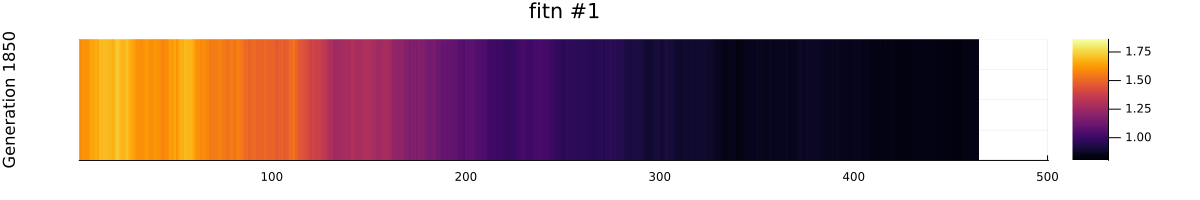

In [59]:
re_heatmap(A,"fitn", N_GENS-150, N_GENS)

In [3]:
oneD1 = deserialize("../paperdata/1.re")

Dict{String, Any} with 5 entries:
  "pops"  => NaN
  "del"   => NaN
  "fitn"  => Float32[1.0 0.999775 … 2.69518 2.69695; 1.0 0.999788 … 2.69652 2.6…
  "stats" => Dict{String, Any}("max"=>(500,), "n_segr_regions"=>20, "wlddim"=>1…
  "ben"   => NaN

In [7]:
oneD1["fitn"]

500×12000×10 Array{Float32, 3}:
[:, :, 1] =
   1.0    0.999775    0.999826    0.999639  …    2.69579  2.69518  2.69695
   1.0    0.999788    0.999608    0.999706       2.68724  2.69652  2.69625
   1.0    0.999741    0.999664    0.999339       2.69318  2.70779  2.71888
   1.0    0.999856    0.999863    0.99994        2.72933  2.73373  2.75156
   1.0    0.999801    0.99969     0.999615       2.74175  2.74627  2.73622
 NaN    NaN         NaN         NaN         …    2.77948  2.77539  2.78398
 NaN    NaN         NaN         NaN              2.76336  2.76693  2.77021
 NaN    NaN         NaN         NaN              2.8058   2.8086   2.81869
 NaN    NaN         NaN         NaN              2.85602  2.86616  2.86863
 NaN    NaN         NaN         NaN              2.86402  2.859    2.86744
   ⋮                                        ⋱                      
 NaN    NaN         NaN         NaN              1.78036  1.78148  1.78074
 NaN    NaN         NaN         NaN              1.77857  1.778

In [14]:
A["fitn"]

500×3001×5 Array{Float32, 3}:
[:, :, 1] =
   1.0    0.99973     0.999467    0.999368  …  1.6696    1.67299   1.6693
   1.0    0.999896    0.999433    0.99915      1.6796    1.67317   1.67398
   1.0    0.999955    0.999652    0.999559     1.67381   1.67466   1.67931
   1.0    0.999904    0.999576    0.999246     1.66762   1.67588   1.68174
   1.0    0.999747    0.999818    0.999635     1.69071   1.69618   1.69308
 NaN    NaN         NaN         NaN         …  1.71866   1.71718   1.71733
 NaN    NaN         NaN         NaN            1.72401   1.72707   1.72715
 NaN    NaN         NaN         NaN            1.75537   1.75494   1.75246
 NaN    NaN         NaN         NaN            1.77882   1.7712    1.7697
 NaN    NaN         NaN         NaN            1.76076   1.76632   1.76652
   ⋮                                        ⋱                      ⋮
 NaN    NaN         NaN         NaN            0.813603  0.813649  0.813516
 NaN    NaN         NaN         NaN            0.813878  0.813884

In [61]:
oneD1 = OrderedDict(oneD1)

OrderedDict{String, Any} with 5 entries:
  "pops"  => NaN
  "del"   => NaN
  "fitn"  => Float32[1.0 0.999775 … 2.69518 2.69695; 1.0 0.999788 … 2.69652 2.6…
  "stats" => Dict{String, Any}("max"=>(500,), "n_segr_regions"=>20, "wlddim"=>1…
  "ben"   => NaN

In [9]:
oneD1["stats"]

Dict{String, Any} with 18 entries:
  "max"               => (500,)
  "n_segr_regions"    => 20
  "wlddim"            => 1
  "r_prolif_rate"     => 2
  "max_burnin"        => (5,)
  "name"              => "2024-07-24_11-14-05"
  "startfill"         => UnitRange{Int64}[1:5]
  "s_sel_coef"        => 0.005
  "n_gens"            => 12000
  "migr_mode"         => "ort"
  "n_gens_exp"        => 2000
  "n_gens_burnin"     => 10000
  "mut_rate"          => 0.05
  "max_exp"           => (500,)
  "k_capacity"        => 100
  "n_demes_startfill" => 5
  "prop_of_del_muts"  => 0.9
  "migr_rate"         => 0.05

In [15]:
A["stats"]

OrderedDict{String, Any} with 18 entries:
  "name"             => "2025-09-16_10-40-42"
  "max"              => (500,)
  "capacity"         => 100
  "prolif_rate"      => 2
  "regions"          => [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005…
  "n_segr_regions"   => 20
  "mut_rate"         => 0.05
  "migr_rate"        => 0.05
  "migr_mode"        => "ort"
  "sel_coef"         => 0.005
  "prop_of_del_muts" => 0.9
  "wlddim"           => 1
  "max_burnin"       => (5,)
  "max_exp"          => (500,)
  "n_gens_burnin"    => 1000
  "n_gens_exp"       => 2000
  "n_gens"           => 3000
  "simtime"          => 144.264

In [80]:
function norm_onset_mean2(data, n_gens_burnin::Int, offset::Int=0)
    normal_array = copy(data)
    n_re = size(data)[end]
    wlddim = length(size(data)) - 2

    for rep in 1:n_re
        sum = 0
        count = 0

        for u in data[repeat([:], wlddim)..., n_gens_burnin + 1 + offset, rep]
            if u > 0
                sum += u
                count += 1
            end
        end

        gen_average = sum / count
        println(gen_average)

        for i in (n_gens_burnin + 1 + offset):size(data, wlddim + 1)
            normal_array[repeat([:], wlddim)..., i, rep] ./= gen_average
        end
    end

    return normal_array
end

norm_onset_mean2 (generic function with 2 methods)

In [ ]:
A_fitn_frontav = average_front(A,"fitn";oneside=true)
A_fitn_frontav_mean = timeseries_mean(A_fitn_frontav, N_GENS)

3000-element Vector{Float32}:
 1.0
 0.99973166
 0.99959296
 0.9995421
 0.9992584
 0.99898595
 0.9986471
 0.9983345
 0.9981389
 0.9978731
 ⋮
 0.69871855
 0.6992369
 0.69896954
 0.69823825
 0.69810337
 0.69866174
 0.6985165
 0.69832575
 0.69848514

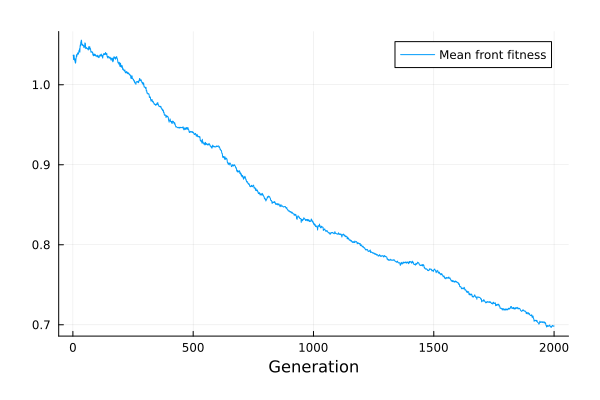

In [76]:
Plots.plot(A_fitn_frontav_mean[(N_GENS_BURNIN+1):end],xlabel="Generation",label="Mean front fitness")

In [85]:
A_fitnN = norm_onset_mean2(A["fitn"],N_GENS_BURNIN)
A_fitnN_frontav = average_front(A_fitnN, N_GENS, X_MAX; oneside=true)
A_fitnN_frontav_mean = timeseries_mean(A_fitnN_frontav, N_GENS)

1.0760071
1.0520494
1.0143213
1.037114
1.0094879


3000-element Vector{Float32}:
 1.0
 0.99973166
 0.99959296
 0.9995421
 0.9992584
 0.99898595
 0.9986471
 0.9983345
 0.9981389
 0.9978731
 ⋮
 0.67301166
 0.6735083
 0.6732419
 0.672533
 0.67241883
 0.6729687
 0.6728307
 0.6726524
 0.6728397

In [ ]:
Plots.plot(A_fitnN_frontav_mean[(N_GENS_BURNIN+1):end],xlabel="Generation",label="Norm. front fitness")

In [48]:
LOCI_N = oneD1["stats"]["n_segr_regions"]
K_CAPACITY = 100
S_SELECT_COEF = 0.005
M_MIG_RATE = 0.05
MUT_RATE = 0.05
MUT_DELETER_RATE = oneD1["stats"]["prop_of_del_muts"]
r_LOG_PROLIF_RATE = log(oneD1["stats"]["r_prolif_rate"])

0.6931471805599453

In [50]:
# Analytical function definitions
# ------------------------------------------------

function N_t(m,r,K,t)
    x_ = (m/2)*K*exp(r*t)
    if x_ >= K
        x_ =  K
    end
    return x_
end

function growth_T(m,r)
    return log(2/m)/r
end

function s_e(s,m,r)
    return s*(m/2)*growth_T(m,r)
end

function x0(s,m,r,K,t)
    x_ = exp(s*(growth_T(m,r)-t))
    x_ /= (exp(s*(growth_T(m,r)-t))+2*N_t(m,r,K,t)-1)
    return x_
end

function u_p_cubic(P,s,m,r,K)
    local myexp = exp(s*growth_T(m,r))
    
    return (3*myexp*(myexp-1)*P-K*m*((myexp-1)*P+1)^3+K*m)/(3*myexp*(myexp-1)-K*m*myexp^3+K*m)
end

h2(s,m,r,K) = sqrt(exp(-s*growth_T(m,r))*K*m) # A* in my PDF
h1(s,m,r) = expm1(s*growth_T(m,r)) # B in my PDF

function u_p(P,s,m,r,K)
    local myh1 = h1(s,m,r)
    local myh2 = h2(s,m,r,K)
    u_ = erf(myh1*myh2*P+myh2)-erf(myh2)
    u_ /= erf(myh1*myh2+myh2)-erf(myh2)
    return u_
end

function u_p_peischl(P,s,m,r,K)
    local mys_e = s_e(s,m,r)
    u_ = expm1(-4*mys_e*K_CAPACITY*P)
    u_ /= expm1(-4*mys_e*K_CAPACITY)
    return u_
end

#= function u_p_alt(P,s,m,r,K)
    myA = s*growth_T(m,r)
    myB = 2/K/m
    u_1 = (-1+0im)^myB * _₂F₁(1,myB,2+myB,1-exp(myA))
    u_ = u_1 / ((P-1+0im)^(1+myB) * exp(-myB*myA) * _₂F₁(myB,1+myB,2+myB,(exp(-myA)-1)*(P-1)) + u_1)
    return u_
end =#
function u_p_alt(P,s,m,r,K)
    myA = expm1(s*growth_T(m,r))
    myB = 2/K/m + 1
    u_ = ((myA*P+1)^myB - 1)/((myA+1)^myB - 1)
    return u_
end

LOCI_N_THEORY = LOCI_N

function large_p(s,m,r,K,t,u,n,phi)
    P_ = 2*N_t(m,K,r,t)*(u/n)*phi*u_p_peischl(x0(s,m,r,K,t),1,m,r,K)
    return P_
end
function large_p_test(s,m,r,K,t,u,n,phi)
    P_ = 2*N_t(m,K,r,t)*(u/n)*phi*u_p_peischl(x0(s,m,r,K,t),s,m,r,K)
    return P_
end
function large_p_test2(s,m,r,K,t,u,n,phi)
    P_ = 2*N_t(m,K,r,t)*(u/n)*phi*u_p(x0(s,m,r,K,t),1,m,r,K)
    return P_
end
function mu_effect(t)
    mu_ = (2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p(S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,1-MUT_DELETER_RATE)
    mu_ += (-2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p(-S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,MUT_DELETER_RATE)
    return mu_
end
function mu_effect_test(t)
    mu_ = (2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p_test(S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,1-MUT_DELETER_RATE)
    mu_ += (-2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p_test(-S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,MUT_DELETER_RATE)
    return mu_
end
function mu_effect_test2(t)
    mu_ = (2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p_test2(S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,1-MUT_DELETER_RATE)
    mu_ += (-2*S_SELECT_COEF+S_SELECT_COEF^2)*large_p_test2(-S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,t,MUT_RATE,LOCI_N_THEORY,MUT_DELETER_RATE)
    return mu_
end

function large_p_2015(s,migr,r,K,mut)
    my_4seK = 4*s_e(s,migr,r)*K
    P_ = -mut*my_4seK/expm1(-my_4seK)
    return P_
end
function mu_effect_2015(t)
    mu_ = 2*S_SELECT_COEF*(1-MUT_DELETER_RATE)*large_p_2015(S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,MUT_RATE)
    mu_ -= 2*S_SELECT_COEF*MUT_DELETER_RATE*large_p_2015(-S_SELECT_COEF,M_MIG_RATE,r_LOG_PROLIF_RATE,K_CAPACITY,MUT_RATE)
    return mu_
end

# Calculate the analytical approximation
# ------------------------------------------------

using QuadGK

function find_mf_theory(start_mf;mu_func=mu_effect)
    my_T = growth_T(M_MIG_RATE,r_LOG_PROLIF_RATE)
    sim_inte_result = quadgk(mu_func,0,my_T)[1]/my_T

    mean_fitness_sim_result = Array{Float64}(undef,0)

    for t_i in 1:N_GENS_BURNIN
        mean_fitness_sim_result = cat(mean_fitness_sim_result,0,dims=1)
    end

    mean_fitness_sim_result = cat(mean_fitness_sim_result,start_mf, dims=1)

    for t_i in (N_GENS_BURNIN+2):N_GENS
        mean_fitness_sim_result = cat(mean_fitness_sim_result,mean_fitness_sim_result[t_i-1]*(1+sim_inte_result)^LOCI_N_THEORY, dims=1)
    end
    return mean_fitness_sim_result
end

find_mf_theory (generic function with 1 method)

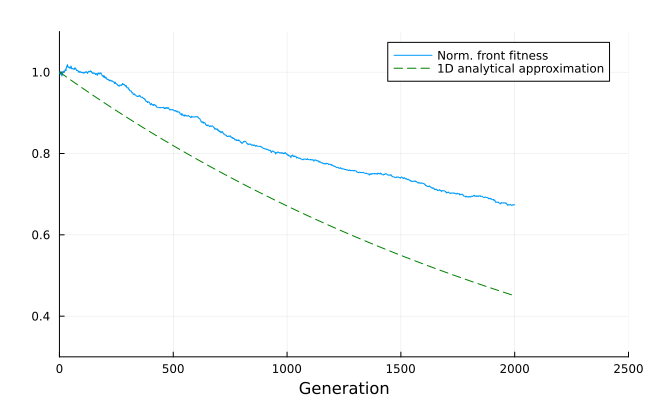

In [71]:
Plots.plot!(find_mf_theory(1;mu_func=mu_effect)[(N_GENS_BURNIN+1):end],label = "1D analytical approximation",color="green",linestyle=:dash,size=(660,420),ylims=(0.3,1.1),xlims=(0,2500))

In [4]:
N_GENS = oneD1["stats"]["n_gens"]
N_GENS_BURNIN = oneD1["stats"]["n_gens_burnin"]
X_MAX = oneD1["stats"]["max"][1]


500

In [ ]:
oneD1_fitn_frontav = average_front(oneD1,"fitn";oneside=true)
oneD1_fitn_frontav_mean = timeseries_mean(oneD1_fitn_frontav, N_GENS)
oneD1_fitnN = norm_onset_mean(oneD1_fitn_frontav_mean,N_GENS_BURNIN)

In [13]:
oneD1_fitnN = norm_onset_mean(oneD1["fitn"],N_GENS_BURNIN)
oneD1_fitnN_frontav = average_front(oneD1_fitnN, N_GENS, X_MAX; oneside=true)
oneD1_fitnN_frontav_mean = average_ts(oneD1_fitnN_frontav, N_GENS)
oneD1_fitnN_frontav_mean2 = norm_onset_mean(oneD1_fitnN_frontav_mean,N_GENS_BURNIN)

12000-element Vector{Float32}:
 1.0014256
 1.0012851
 1.00116
 1.0010253
 1.0009162
 1.0007403
 1.0007015
 1.0005084
 1.0003146
 1.0001428
 ⋮
 0.81049824
 0.80974287
 0.80991733
 0.81041336
 0.8099888
 0.8099144
 0.8092989
 0.8095531
 0.80911374

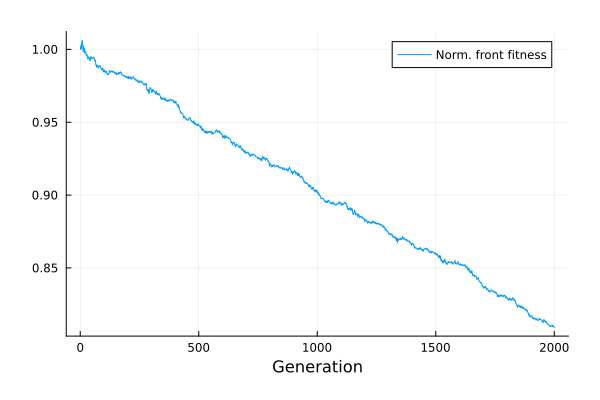

In [15]:
Plots.plot(oneD1_fitnN_frontav_mean2[(N_GENS_BURNIN+1):end],xlabel="Generation",label="Norm. front fitness")